Webcam recording skipped. The next cell will use a video from /content.
Using video: /content/webcam_input.webm
Video file size: 5.71 MB
Converted WebM to constant 30 FPS MP4: /content/.fall_detection_tmp/webcam_input_fixed30fps.mp4
Video used for inference: /content/.fall_detection_tmp/webcam_input_fixed30fps.mp4
Video information
------------------------------
Frames : 580
FPS    : 30.0
Size   : 640 x 480
Using uploaded checkpoint: /content/fold2_best.pth
Checkpoint size: 3.53 MB
Checkpoint type:
<class 'dict'>

Checkpoint keys:
   model_state_dict
   epoch
   validation_loss
   channel_mean
   channel_std
   selected_features
   config
   seed
   fold
Model architecture from checkpoint: hidden=128, kernel=7, dilations=[1, 2, 4, 8]
Selected features: ['orientation', 'center_vel', 'bbox', 'center_acc', 'center_pos', 'angular_vel']
Input channels    : 13

Model loaded successfully.
Mean shape: (13,)
Std shape : (13,)
Video: 580 frames | 30.00 FPS | 640x480

Extracting poses...
Processe

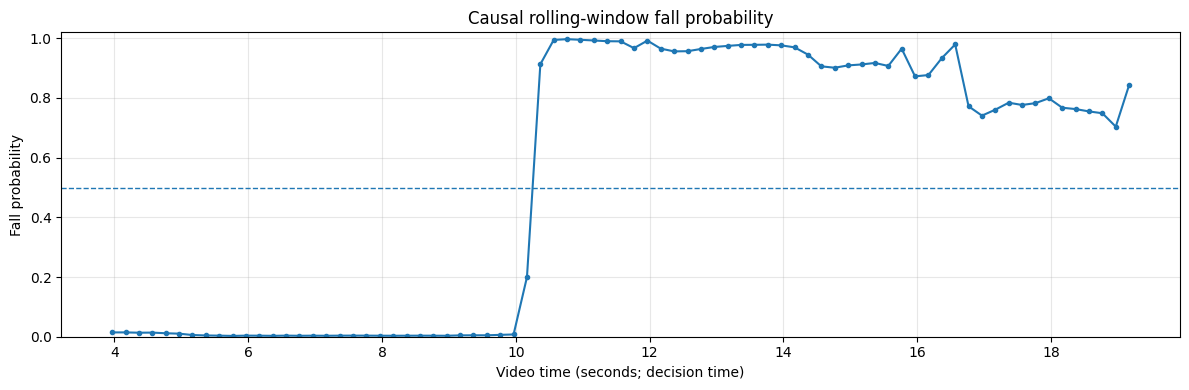


Creating causal annotated video...
Annotated 575/580 frames

Done. Causal annotated video saved to:
/content/fall_detection_causal_annotated.mp4
Probability timeline saved to:
/content/fall_detection_causal_scores.csv


In [11]:
# Causal fall detection with webcam recording

# CELL 1 — RECORD A VIDEO USING YOUR BROWSER WEBCAM (COLAB)
# ============================================================

from pathlib import Path
from base64 import b64decode
from IPython.display import Javascript, display
from google.colab import output

# True: record a fresh webcam clip below.
# False: skip recording and use a video already uploaded to /content.
RECORD_WEBCAM = False
RECORD_SECONDS = 10
RECORDING_PATH = Path("/content/webcam_input.webm")

if RECORD_WEBCAM:
    display(Javascript(r"""
    async function recordWebcam(seconds) {
        const video = document.createElement("video");
        video.style.width = "640px";
        video.style.display = "block";
        video.autoplay = true;
        video.muted = true;
        video.playsInline = true;

        const status = document.createElement("div");
        status.style.fontSize = "18px";
        status.style.margin = "10px 0";
        status.innerText = "Requesting webcam access...";

        document.body.appendChild(status);
        document.body.appendChild(video);

        let stream = null;
        try {
            stream = await navigator.mediaDevices.getUserMedia({
                video: true,
                audio: false
            });
            video.srcObject = stream;
            await video.play();

            // Use WebM recording; the next cell converts it to fixed 30 FPS MP4.
            const options = MediaRecorder.isTypeSupported("video/webm;codecs=vp9")
                ? {mimeType: "video/webm;codecs=vp9"}
                : {mimeType: "video/webm"};
            const recorder = new MediaRecorder(stream, options);
            const chunks = [];

            recorder.ondataavailable = event => {
                if (event.data && event.data.size > 0) chunks.push(event.data);
            };

            recorder.start();
            for (let remaining = seconds; remaining > 0; remaining--) {
                status.innerText = "Recording... " + remaining + " seconds remaining";
                await new Promise(resolve => setTimeout(resolve, 1000));
            }

            status.innerText = "Finishing recording...";
            const stopped = new Promise(resolve => { recorder.onstop = resolve; });
            recorder.stop();
            await stopped;

            const blob = new Blob(chunks, {type: "video/webm"});
            const dataUrl = await new Promise((resolve, reject) => {
                const reader = new FileReader();
                reader.onloadend = () => resolve(reader.result);
                reader.onerror = reject;
                reader.readAsDataURL(blob);
            });
            return dataUrl.split(",")[1];
        } finally {
            if (stream) stream.getTracks().forEach(track => track.stop());
            video.remove();
            status.remove();
        }
    }
    """))

    print("Allow webcam access if your browser asks.")
    recorded_data = output.eval_js(f"recordWebcam({int(RECORD_SECONDS)})")
    if not recorded_data:
        raise RuntimeError("The webcam recording returned no data.")

    recorded_bytes = b64decode(recorded_data)
    if not recorded_bytes:
        raise RuntimeError("The webcam recording file is empty.")

    RECORDING_PATH.write_bytes(recorded_bytes)
    print(f"Webcam recording saved: {RECORDING_PATH}")
    print(f"Recording size: {len(recorded_bytes) / (1024 * 1024):.2f} MB")
else:
    print("Webcam recording skipped. The next cell will use a video from /content.")


# ============================================================

# CELL 2 — SELECT VIDEO AND CONVERT TO CONSTANT 30 FPS
# ============================================================

from pathlib import Path
import cv2
import numpy as np

LOCAL_DIR = Path("/content")

# Used only when RECORD_WEBCAM is False. Set an exact filename if more than
# one video is uploaded, e.g. VIDEO_FILENAME = "my_test_video.mp4".
VIDEO_FILENAME = None
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv", ".webm", ".mpeg", ".mpg"}

if RECORD_WEBCAM:
    VIDEO_PATH = RECORDING_PATH
    if not VIDEO_PATH.is_file():
        raise FileNotFoundError(
            f"The webcam recording was not found at {VIDEO_PATH}. "
            "Run Cell 1 again, or set RECORD_WEBCAM = False to use an uploaded video."
        )
else:
    if VIDEO_FILENAME is not None:
        # An explicit filename always takes priority.
        VIDEO_PATH = LOCAL_DIR / VIDEO_FILENAME
        if not VIDEO_PATH.is_file():
            raise FileNotFoundError(
                f"Video not found: {VIDEO_PATH}. Upload it to /content or correct VIDEO_FILENAME."
            )
    else:
        # If recording was skipped, first reuse the default webcam recording
        # from an earlier cell/run. The previous version mistakenly excluded it.
        preferred_videos = [
            LOCAL_DIR / "webcam_input.webm",
            LOCAL_DIR / "webcam_input.mp4",
        ]
        VIDEO_PATH = next((p for p in preferred_videos if p.is_file()), None)

        if VIDEO_PATH is None:
            # Otherwise discover videos uploaded directly into /content.
            video_candidates = sorted(
                p for p in LOCAL_DIR.iterdir()
                if p.is_file()
                and p.suffix.lower() in VIDEO_EXTENSIONS
                and p.name.lower() != "fall_detection_annotated.mp4"
            )

            if len(video_candidates) == 0:
                raise FileNotFoundError(
                    "No video was found in /content. If the previous runtime was reset, "
                    "its webcam recording may have been deleted; record again or upload a video. "
                    "You can also set VIDEO_FILENAME in Cell 2."
                )
            if len(video_candidates) > 1:
                names = "\n".join(f"  - {p.name}" for p in video_candidates)
                raise RuntimeError(
                    "More than one video was found. Set VIDEO_FILENAME in Cell 2. "
                    f"Candidates:\n{names}"
                )
            VIDEO_PATH = video_candidates[0]

print(f"Using video: {VIDEO_PATH}")
print(f"Video file size: {VIDEO_PATH.stat().st_size / (1024 * 1024):.2f} MB")

# Browser-recorded WebM files can report a misleading FPS (e.g. 1000 FPS).
# Re-encode WebM to constant 30 FPS before pose extraction.
if VIDEO_PATH.suffix.lower() == ".webm":
    import subprocess

    conversion_dir = LOCAL_DIR / ".fall_detection_tmp"
    conversion_dir.mkdir(parents=True, exist_ok=True)
    converted_video = conversion_dir / f"{VIDEO_PATH.stem}_fixed30fps.mp4"

    subprocess.run(
        [
            "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",
            "-i", str(VIDEO_PATH),
            "-vf", "fps=30", "-r", "30",
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            str(converted_video),
        ],
        check=True,
    )
    VIDEO_PATH = converted_video
    print(f"Converted WebM to constant 30 FPS MP4: {VIDEO_PATH}")

INPUT_VIDEO = str(VIDEO_PATH)
print(f"Video used for inference: {INPUT_VIDEO}")

_cap = cv2.VideoCapture(INPUT_VIDEO)
if not _cap.isOpened():
    raise RuntimeError(f"OpenCV could not open the selected video: {INPUT_VIDEO}")
_video_frames = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))
_video_fps = _cap.get(cv2.CAP_PROP_FPS)
_video_width = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
_video_height = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
_cap.release()

print("Video information")
print("------------------------------")
print("Frames :", _video_frames)
print("FPS    :", _video_fps)
print("Size   :", f"{_video_width} x {_video_height}")


# ============================================================

# CELL 3 — USE THE CHECKPOINT UPLOADED TO THE CURRENT COLAB SESSION
# ============================================================

from pathlib import Path

# Colab's Files panel uploads files to /content by default.
# Optional: enter the exact checkpoint filename if multiple checkpoints exist.
# Example: CHECKPOINT_FILENAME = "trunktcn_checkpoint.pt"
CHECKPOINT_FILENAME = None

CHECKPOINT_EXTENSIONS = {".pt", ".pth", ".ckpt"}

if CHECKPOINT_FILENAME is not None:
    CHECKPOINT_PATH = LOCAL_DIR / CHECKPOINT_FILENAME
    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(
            f"Checkpoint not found: {CHECKPOINT_PATH}\n"
            f"Upload it to {LOCAL_DIR} or set CHECKPOINT_FILENAME correctly."
        )
else:
    checkpoint_candidates = sorted(
        p for p in LOCAL_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in CHECKPOINT_EXTENSIONS
    )

    if len(checkpoint_candidates) == 0:
        raise FileNotFoundError(
            f"No checkpoint (.pt, .pth, or .ckpt) was found directly inside {LOCAL_DIR}.\n"
            "Upload the trained checkpoint using the Colab Files panel, then rerun this cell."
        )
    if len(checkpoint_candidates) > 1:
        names = "\n".join(f"  - {p.name}" for p in checkpoint_candidates)
        raise RuntimeError(
            "More than one checkpoint was found. Set CHECKPOINT_FILENAME "
            f"near the top of this cell to the intended file. Candidates:\n{names}"
        )

    CHECKPOINT_PATH = checkpoint_candidates[0]

CHECKPOINT_PATH = str(CHECKPOINT_PATH)
print(f"Using uploaded checkpoint: {CHECKPOINT_PATH}")
print(f"Checkpoint size: {Path(CHECKPOINT_PATH).stat().st_size / (1024 * 1024):.2f} MB")


# ============================================================

# CELL 3A — INSPECT CHECKPOINT
# ============================================================

import torch

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint type:")
print(type(checkpoint))

if isinstance(checkpoint, dict):

    print("\nCheckpoint keys:")

    for k in checkpoint.keys():
        print("  ", k)

else:

    print("\nCheckpoint is not a dictionary.")

# ============================================================

# CELL 4 — SELF-CONTAINED MODEL + PREPROCESSING
# ============================================================

import math
import re
import cv2
import numpy as np
import torch
import torch.nn as nn

from scipy.signal import savgol_filter


# ============================================================
# 1. TRAINING CONFIGURATION
# ============================================================

TARGET_FPS = 25.0

NUM_JOINTS = 13

HARD_CONF = 0.5
SOFT_CONF = 0.3

MIN_CLEAN_FRAMES = 5
MIN_OUTPUT_FRAMES = 16

SG_WINDOW = 7
SG_POLY = 2

MIN_SCALE_PX = 2.0

WINDOW_MODE = "mil"
WINDOW_LEN = 100
WINDOW_STRIDE = 25

MIL_POOL = "max"
MIL_K = 3
MIL_LSE_R = 2.0

NORM_SCOPE = "sequence"

# Infer shape-dependent architecture parameters from the uploaded checkpoint.
# This checkpoint's weights indicate hidden=128 and kernel=7 (rather than
# hidden=64 and kernel=11, which caused the load_state_dict size mismatch).
_MODEL_STATE = checkpoint["model_state_dict"]
try:
    TCN_HIDDEN = int(_MODEL_STATE["inp.weight"].shape[0])
    TCN_KERNEL = int(_MODEL_STATE["blocks.0.conv1.weight"].shape[-1])
except (KeyError, IndexError, TypeError) as exc:
    raise RuntimeError(
        "Could not infer TCN_HIDDEN / TCN_KERNEL from checkpoint model_state_dict."
    ) from exc

# Dilation values cannot be inferred from weight shapes. Use a dilation list
# saved in checkpoint config if present; otherwise retain this training setup.
def _find_dilations(config):
    if isinstance(config, dict):
        for key, value in config.items():
            if "dilat" in str(key).lower() and isinstance(value, (list, tuple)):
                if value and all(isinstance(v, (int, float)) for v in value):
                    return [int(v) for v in value]
            found = _find_dilations(value)
            if found is not None:
                return found
    elif isinstance(config, (list, tuple)):
        for value in config:
            found = _find_dilations(value)
            if found is not None:
                return found
    return None

TCN_DILATIONS = _find_dilations(checkpoint.get("config", {})) or [1, 2, 4, 8]

_block_indices = sorted({
    int(key.split(".")[1])
    for key in _MODEL_STATE
    if key.startswith("blocks.") and key.split(".")[1].isdigit()
})
if _block_indices != list(range(len(_block_indices))):
    raise RuntimeError(f"Unexpected TCN block indices in checkpoint: {_block_indices}")
if len(TCN_DILATIONS) != len(_block_indices):
    raise RuntimeError(
        f"Checkpoint has {len(_block_indices)} TCN blocks, but the selected dilation "
        f"list is {TCN_DILATIONS}. Check checkpoint['config'] for the training dilations."
    )

DROPOUT = 0.5
NUM_CLASSES = 2

print(
    "Model architecture from checkpoint: "
    f"hidden={TCN_HIDDEN}, kernel={TCN_KERNEL}, dilations={TCN_DILATIONS}"
)


# ============================================================
# 2. FEATURE DEFINITIONS — EXACT TRAINING VERSION
# ============================================================

FEATURE_GROUPS = {

    "start_pos": [
        ("start_x", -1, "pos_x"),
        ("start_y", 1, "pos_y")
    ],

    "end_pos": [
        ("end_x", -1, "pos_x"),
        ("end_y", 1, "pos_y")
    ],

    "center_pos": [
        ("center_x", -1, "pos_x"),
        ("center_y", 1, "pos_y")
    ],

    "orientation": [
        ("axis_ux", -1, "none"),
        ("axis_uy", 1, "none"),
        ("trunk_length", 1, "len")
    ],

    "start_vel": [
        ("start_vx", -1, "len"),
        ("start_vy", 1, "len")
    ],

    "end_vel": [
        ("end_vx", -1, "len"),
        ("end_vy", 1, "len")
    ],

    "center_vel": [
        ("center_vx", -1, "len"),
        ("center_vy", 1, "len")
    ],

    "center_acc": [
        ("center_ax", -1, "len"),
        ("center_ay", 1, "len")
    ],

    "angular_vel": [
        ("axis_angular_velocity", -1, "none")
    ],

    "bbox": [
        ("bbox_width", 1, "len"),
        ("bbox_height", 1, "len"),
        ("bbox_log_aspect", 1, "none")
    ],

    "quality": [
        ("unreliable_flag", 1, "none")
    ],
}


# ------------------------------------------------------------
# Use the checkpoint's selected features
# ------------------------------------------------------------

SELECTED_FEATURES = list(
    checkpoint["selected_features"]
)

_COLS = [
    c
    for g in SELECTED_FEATURES
    for c in FEATURE_GROUPS[g]
]

SELECTED_FEATURE_NAMES = [
    c[0] for c in _COLS
]

MIRROR_SIGN = np.array(
    [c[1] for c in _COLS],
    dtype=np.float32
)

POS_X_COLS = np.array(
    [
        i for i, c in enumerate(_COLS)
        if c[2] == "pos_x"
    ],
    dtype=np.int64
)

POS_Y_COLS = np.array(
    [
        i for i, c in enumerate(_COLS)
        if c[2] == "pos_y"
    ],
    dtype=np.int64
)

LEN_COLS = np.array(
    [
        i for i, c in enumerate(_COLS)
        if c[2] == "len"
    ],
    dtype=np.int64
)

INPUT_CHANNELS = len(_COLS)


print("Selected features:", SELECTED_FEATURES)
print("Input channels    :", INPUT_CHANNELS)


# ============================================================
# 3. TRAINING MODEL — EXACT ARCHITECTURE
# ============================================================

class ChannelNorm(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.ln = nn.LayerNorm(
            channels
        )

    def forward(self, x):

        return self.ln(
            x.transpose(1, 2)
        ).transpose(1, 2)


class ResidualTCNBlock(nn.Module):

    def __init__(
        self,
        channels,
        kernel,
        dilation,
        dropout
    ):

        super().__init__()

        pad = (
            dilation *
            (kernel - 1) // 2
        )

        self.conv1 = nn.Conv1d(
            channels,
            channels,
            kernel,
            padding=pad,
            dilation=dilation
        )

        self.norm1 = ChannelNorm(
            channels
        )

        self.conv2 = nn.Conv1d(
            channels,
            channels,
            kernel,
            padding=pad,
            dilation=dilation
        )

        self.norm2 = ChannelNorm(
            channels
        )

        self.act = nn.GELU()

        self.drop = nn.Dropout(
            dropout
        )

    def forward(self, x, mask):

        h = self.drop(
            self.act(
                self.norm1(
                    self.conv1(
                        x * mask
                    )
                )
            )
        )

        h = self.norm2(
            self.conv2(
                h * mask
            )
        )

        return self.act(
            x + h
        ) * mask


class TrunkTCN(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden,
        kernel,
        dilations,
        dropout,
        num_classes
    ):

        super().__init__()

        self.inp = nn.Conv1d(
            in_channels,
            hidden,
            1
        )

        self.blocks = nn.ModuleList([
            ResidualTCNBlock(
                hidden,
                kernel,
                d,
                dropout
            )
            for d in dilations
        ])

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(
                2 * hidden,
                num_classes
            )
        )

    def forward(self, x, mask):

        x = self.inp(
            x * mask
        ) * mask

        for block in self.blocks:

            x = block(
                x,
                mask
            )

        x_max = x.masked_fill(
            mask == 0,
            -1e9
        ).max(dim=2).values

        x_mean = (
            (x * mask).sum(dim=2)
            /
            mask.sum(dim=2).clamp(min=1.0)
        )

        return self.head(
            torch.cat(
                [x_max, x_mean],
                dim=1
            )
        )


def make_model():

    return TrunkTCN(
        INPUT_CHANNELS,
        TCN_HIDDEN,
        TCN_KERNEL,
        TCN_DILATIONS,
        DROPOUT,
        NUM_CLASSES
    )


# ============================================================
# 4. LOAD TRAINED MODEL
# ============================================================

model = make_model()

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

model.eval()


# ============================================================
# 5. TRAINING NORMALIZATION
# ============================================================

mean = np.asarray(
    checkpoint["channel_mean"],
    dtype=np.float32
)

std = np.asarray(
    checkpoint["channel_std"],
    dtype=np.float32
)

std = np.where(
    std < 1e-6,
    1.0,
    std
)

print("\nModel loaded successfully.")
print("Mean shape:", mean.shape)
print("Std shape :", std.shape)


# ============================================================
# 6. TRUNK NODE FUNCTIONS
# ============================================================

SH, HIP, LEG = (
    [1, 4],
    [7, 10],
    [8, 9, 11, 12]
)


def unit(v):

    n = np.linalg.norm(v)

    return (
        v / n
        if n > 1e-6
        else None
    )


def _group_pts(
    sk,
    cf,
    joints,
    thr
):
    # A missing joint has NaN coordinates and normally confidence 0.
    # IMPORTANT: NaN * 0 is still NaN, so mask coordinates before
    # multiplying them by confidence weights.
    coords = sk[:, joints, :]
    c = cf[:, joints]

    valid = (
        (c >= thr)
        & np.isfinite(c)
        & np.isfinite(coords).all(axis=2)
    )
    w = np.where(valid, c, 0.0)

    ws = w.sum(axis=1)

    safe_coords = np.where(
        valid[:, :, None],
        coords,
        0.0
    )
    weighted_sum = (
        safe_coords * w[:, :, None]
    ).sum(axis=1)

    pts = weighted_sum / np.maximum(
        ws,
        1e-12
    )[:, None]

    return pts, ws > 0


def estimate_nodes(
    sk,
    cf
):

    T = len(sk)

    S = np.full(
        (T, 2),
        np.nan
    )

    E = np.full(
        (T, 2),
        np.nan
    )

    Q = np.full(
        T,
        4,
        dtype=np.int64
    )

    s0, sok = _group_pts(
        sk,
        cf,
        HIP,
        HARD_CONF
    )

    e0, eok = _group_pts(
        sk,
        cf,
        SH,
        HARD_CONF
    )

    q0 = sok & eok

    S[q0] = s0[q0]
    E[q0] = e0[q0]
    Q[q0] = 0

    s2, s2ok = _group_pts(
        sk,
        cf,
        HIP,
        SOFT_CONF
    )

    e2, e2ok = _group_pts(
        sk,
        cf,
        SH,
        SOFT_CONF
    )

    if q0.sum() >= MIN_CLEAN_FRAMES:

        L_ref = float(
            np.median(
                np.linalg.norm(
                    E[q0] - S[q0],
                    axis=1
                )
            )
        )

    else:

        both = s2ok & e2ok

        if both.sum() < MIN_CLEAN_FRAMES:
            raise ValueError(
                "cannot estimate trunk length"
            )

        L_ref = float(
            np.median(
                np.linalg.norm(
                    e2[both] - s2[both],
                    axis=1
                )
            )
        )

    if not np.isfinite(L_ref) or L_ref < 1e-3:

        raise ValueError(
            f"invalid trunk length estimate: {L_ref}. "
            "Check pose confidence and valid shoulder/hip coordinates."
        )

    lc, lok = _group_pts(
        sk,
        cf,
        LEG,
        HARD_CONF
    )

    last_q0 = np.maximum.accumulate(
        np.where(
            q0,
            np.arange(T),
            -1
        )
    )

    prev_idx = -1
    prev_dir = None

    for t in np.flatnonzero(~q0):

        j0 = (
            int(last_q0[t - 1])
            if t > 0
            else -1
        )

        pd = (
            unit(E[j0] - S[j0])
            if j0 > prev_idx
            else prev_dir
        )

        s = (
            s0[t]
            if sok[t]
            else None
        )

        e = (
            e0[t]
            if eok[t]
            else None
        )

        l = (
            lc[t]
            if lok[t]
            else None
        )

        if (
            s is None
            and e is not None
            and l is not None
            and unit(l - e) is not None
        ):

            S[t] = (
                e +
                L_ref * unit(l - e)
            )

            E[t] = e
            Q[t] = 1

        elif (
            e is None
            and s is not None
            and l is not None
            and unit(s - l) is not None
        ):

            S[t] = s

            E[t] = (
                s +
                L_ref * unit(s - l)
            )

            Q[t] = 1

        elif (
            s2ok[t]
            and e2ok[t]
        ):

            S[t] = s2[t]
            E[t] = e2[t]
            Q[t] = 2

        elif (
            pd is not None
            and
            (cf[t] >= SOFT_CONF).sum() >= 3
        ):

            idx = np.flatnonzero(
                cf[t] >= SOFT_CONF
            )

            ctr = sk[t, idx].mean(
                axis=0
            )

            a = np.linalg.svd(
                sk[t, idx] - ctr
            )[2][0]

            a = (
                a
                if a @ pd >= 0
                else -a
            )

            S[t] = (
                ctr -
                0.5 * L_ref * a
            )

            E[t] = (
                ctr +
                0.5 * L_ref * a
            )

            Q[t] = 3

        if Q[t] < 4:

            prev_idx = int(t)

            prev_dir = unit(
                E[t] - S[t]
            )

    return S, E, Q


def bbox_series(
    sk,
    cf
):

    m_hard = (
        cf >= HARD_CONF
    )

    m_soft = (
        cf >= SOFT_CONF
    )

    use = np.where(
        (
            m_hard.sum(axis=1)
            >= 4
        )[:, None],
        m_hard,
        m_soft
    )

    big = 1e18

    W = (
        np.where(
            use,
            sk[:, :, 0],
            -big
        ).max(axis=1)
        -
        np.where(
            use,
            sk[:, :, 0],
            big
        ).min(axis=1)
    )

    H = (
        np.where(
            use,
            sk[:, :, 1],
            -big
        ).max(axis=1)
        -
        np.where(
            use,
            sk[:, :, 1],
            big
        ).min(axis=1)
    )

    bad = (
        use.sum(axis=1) < 3
    )

    W[bad] = np.nan
    H[bad] = np.nan

    return W, H


def sg(
    P,
    deriv=0
):

    return savgol_filter(
        np.asarray(
            P,
            dtype=np.float64
        ),
        SG_WINDOW,
        SG_POLY,
        deriv=deriv,
        delta=1.0,
        axis=0,
        mode="interp"
    )


# ============================================================
# 7. FEATURE EXTRACTION — SAME AS TRAINING
# ============================================================

def derive_features(
    sk,
    cf,
    times
):

    if len(times) < 2:
        raise ValueError(
            "too few frames"
        )

    dts = np.diff(times)

    if np.any(dts <= 0):
        raise ValueError(
            "timestamps must increase"
        )

    S, E, Q = estimate_nodes(
        sk,
        cf
    )

    ok = (
        np.isfinite(S).all(axis=1)
        & np.isfinite(E).all(axis=1)
    )

    if ok.sum() < 2:
        raise ValueError(
            "fewer than 2 resolved frames"
        )

    Wb, Hb = bbox_series(
        sk,
        cf
    )

    okb = np.isfinite(Wb) & np.isfinite(Hb)

    if okb.sum() < 2:
        raise ValueError(
            "bounding box unavailable"
        )

    tgrid = np.arange(
        times[0],
        times[-1] + 1e-9,
        1.0 / TARGET_FPS
    )

    if len(tgrid) < MIN_OUTPUT_FRAMES:

        raise ValueError(
            f"only {len(tgrid)} frames after resampling"
        )

    def interp2(P):

        return np.stack(
            [
                np.interp(
                    tgrid,
                    times[ok],
                    P[ok, k]
                )
                for k in range(2)
            ],
            axis=1
        )

    S_i = interp2(S)
    E_i = interp2(E)

    W_i = np.interp(
        tgrid,
        times[okb],
        Wb[okb]
    )

    H_i = np.interp(
        tgrid,
        times[okb],
        Hb[okb]
    )

    dt_med = float(
        np.median(dts)
    )

    j = np.clip(
        np.searchsorted(
            times,
            tgrid
        ),
        1,
        len(times) - 1
    )

    nearest = np.where(
        np.abs(
            times[j - 1] - tgrid
        )
        <=
        np.abs(
            times[j] - tgrid
        ),
        j - 1,
        j
    )

    Q_i = Q[
        nearest
    ].copy()

    Q_i[
        np.abs(
            times[nearest] - tgrid
        )
        >
        0.75 * dt_med
    ] = 4

    unreliable = (
        Q_i > 0
    ).astype(
        np.float64
    )

    C_i = (
        S_i + E_i
    ) / 2.0

    Ss = sg(S_i)
    Es = sg(E_i)
    Cs = sg(C_i)

    a = Es - Ss

    L = np.linalg.norm(
        a,
        axis=1
    )

    u = (
        a /
        np.maximum(
            L,
            1e-6
        )[:, None]
    )

    angle = np.unwrap(
        np.arctan2(
            u[:, 1],
            u[:, 0]
        )
    )

    Ws = np.clip(
        sg(W_i),
        0,
        None
    )

    Hs = np.clip(
        sg(H_i),
        0,
        None
    )

    eps = (
        0.1 *
        max(
            float(np.median(L)),
            1.0
        )
    )

    groups = {

        "start_pos": Ss,

        "end_pos": Es,

        "center_pos": Cs,

        "orientation":
            np.column_stack([
                u,
                L
            ]),

        "start_vel":
            sg(S_i, 1),

        "end_vel":
            sg(E_i, 1),

        "center_vel":
            sg(C_i, 1),

        "center_acc":
            sg(C_i, 2),

        "angular_vel":
            sg(angle[:, None], 1),

        "bbox":
            np.column_stack([
                Ws,
                Hs,
                np.log(
                    (Ws + eps)
                    /
                    (Hs + eps)
                )
            ]),

        "quality":
            unreliable[:, None],
    }

    groups = {
        k: np.asarray(
            v,
            dtype=np.float32
        )
        for k, v in groups.items()
    }

    return {
        "groups": groups,
        "scale": L.astype(
            np.float32
        ),
        "center": Cs.astype(
            np.float32
        ),
        "num_frames":
            len(tgrid),
        "quality_counts":
            np.bincount(
                Q_i,
                minlength=5
            )
    }


# ============================================================
# 8. NORMALIZATION
# ============================================================

def pack_source(F):

    X = np.concatenate(
        [
            F["groups"][g]
            for g in SELECTED_FEATURES
        ],
        axis=1
    ).astype(np.float32)

    return (
        X,
        F["scale"],
        F["center"]
    )


def norm_ref(
    scale,
    center
):

    L = float(
        np.median(scale)
    )

    if (
        not np.isfinite(L)
        or
        L < MIN_SCALE_PX
    ):

        L = MIN_SCALE_PX

    return (
        L,
        center.mean(axis=0)
    )


def apply_norm(
    X,
    L,
    c
):

    Y = X.copy()

    Y[:, POS_X_COLS] = (
        X[:, POS_X_COLS] - c[0]
    ) / L

    Y[:, POS_Y_COLS] = (
        X[:, POS_Y_COLS] - c[1]
    ) / L

    Y[:, LEN_COLS] = (
        X[:, LEN_COLS] / L
    )

    return Y


# ============================================================
# 9. WINDOWING
# ============================================================

def window_starts(
    T,
    W,
    stride
):

    if T <= W:
        return [0]

    starts = list(
        range(
            0,
            T - W + 1,
            stride
        )
    )

    if (
        not starts
        or
        starts[-1] != T - W
    ):

        starts.append(
            T - W
        )

    return starts

# ============================================================

# CELL 5 — MOVENET
# ============================================================

!pip -q install tensorflow-hub

import tensorflow as tf
import tensorflow_hub as hub


movenet = hub.load(
    "https://tfhub.dev/google/movenet/singlepose/lightning/4"
).signatures["serving_default"]


MOVENET_TO_TRUNK = {

    5: 1,
    6: 4,

    7: 2,
    8: 5,

    9: 3,
    10: 6,

    11: 7,
    12: 10,

    13: 8,
    14: 11,

    15: 9,
    16: 12
}


POSE_CONF_THRESHOLD = 0.20
MIN_VALID_JOINT_RATIO = 0.70


def movenet_infer(frame_bgr):

    h, w = frame_bgr.shape[:2]

    # OpenCV BGR -> RGB
    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB
    )

    # Square padding
    side = max(h, w)

    padded = np.zeros(
        (side, side, 3),
        dtype=np.uint8
    )

    padded[:h, :w] = frame_rgb

    # MoveNet input
    img = tf.image.resize_with_pad(
        tf.expand_dims(
            padded,
            axis=0
        ),
        192,
        192
    )

    img = tf.cast(
        img,
        tf.int32
    )

    kp = movenet(
        img
    )["output_0"].numpy()[0, 0]

    xy = np.full(
        (13, 2),
        np.nan,
        dtype=np.float32
    )

    cf = np.zeros(
        13,
        dtype=np.float32
    )

    for (
        mv_idx,
        trunk_idx
    ) in MOVENET_TO_TRUNK.items():

        y, x, score = kp[
            mv_idx
        ]

        if (
            not np.isfinite(score)
            or
            score < POSE_CONF_THRESHOLD
        ):
            continue

        px = float(
            x * side
        )

        py = float(
            y * side
        )

        if not (
            np.isfinite(px)
            and
            np.isfinite(py)
        ):
            continue

        xy[trunk_idx] = [
            px,
            py
        ]

        cf[trunk_idx] = score

    # Neck = shoulder midpoint
    if (
        cf[1] >= POSE_CONF_THRESHOLD
        and
        cf[4] >= POSE_CONF_THRESHOLD
    ):

        xy[0] = (
            xy[1] + xy[4]
        ) / 2.0

        cf[0] = min(
            cf[1],
            cf[4]
        )

    # Reject poor detections
    valid = (
        np.isfinite(
            xy
        ).all(axis=1)
        &
        (
            cf >=
            POSE_CONF_THRESHOLD
        )
    )

    min_valid = int(
        np.ceil(
            MIN_VALID_JOINT_RATIO
            * 13
        )
    )

    if valid.sum() < min_valid:

        xy[:] = np.nan
        cf[:] = 0.0

    return xy, cf

# ============================================================

# CELL 6 — CAUSAL WINDOW-BASED INFERENCE + ANNOTATED VIDEO
# ============================================================

import cv2
import gc
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt

INPUT_VIDEO = str(VIDEO_PATH)
OUTPUT_VIDEO_BOX = str(LOCAL_DIR / "fall_detection_causal_annotated.mp4")
OUTPUT_SCORES_CSV = str(LOCAL_DIR / "fall_detection_causal_scores.csv")

# Make one prediction every 0.2 seconds (5 predictions/second).
# Each prediction uses the preceding WINDOW_LEN / TARGET_FPS seconds only.
CAUSAL_SCORE_INTERVAL_SECONDS = 0.20
FALL_THRESHOLD = 0.50

# ============================================================
# PASS 1 — EXTRACT POSES FROM EACH FRAME
# ============================================================

cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS)
if not np.isfinite(fps) or fps <= 0:
    fps = 30.0

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
metadata_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(
    f"Video: {metadata_frame_count} frames | {fps:.2f} FPS | "
    f"{width}x{height}"
)
print("\nExtracting poses...")

all_sk, all_cf, all_t = [], [], []
frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    xy, cf_frame = movenet_infer(frame)
    all_sk.append(xy)
    all_cf.append(cf_frame)
    all_t.append(frame_idx / fps)
    frame_idx += 1

    if frame_idx % 25 == 0:
        print(f"\rProcessed {frame_idx}/{metadata_frame_count} frames", end="")

cap.release()

sk = np.asarray(all_sk, dtype=np.float64)
cf = np.asarray(all_cf, dtype=np.float64)
times = np.asarray(all_t, dtype=np.float64)
frame_count = len(sk)
if frame_count < 2:
    raise RuntimeError(f"Too few frames were read from {INPUT_VIDEO}")

del all_sk, all_cf, all_t
gc.collect()

print(f"\nFinished pose extraction: {frame_count} frames")
print("Skeleton shape:", sk.shape)
print("Confidence shape:", cf.shape)

# ============================================================
# MIRROR TEST-TIME AUGMENTATION — SAME CHECKPOINT SETTINGS
# ============================================================

_cfg = checkpoint.get("config", {})
if not isinstance(_cfg, dict):
    _cfg = {}
MIRROR_TTA = bool(_cfg.get("mirror_tta", True))
MIRROR_ENABLED = "mirror" in _cfg.get("aug_enable", [])
MODEL_DEVICE = next(model.parameters()).device

# ============================================================
# CAUSAL PREDICTION FUNCTION
# ============================================================

def predict_from_prefix(end_frame_idx):
    """Predict at end_frame_idx using only frames 0..end_frame_idx.

    Features and sequence-level normalization are recomputed on this prefix,
    so no coordinates, timestamps, or normalization statistics from later
    frames can influence this prediction.
    """
    end = int(end_frame_idx) + 1
    prefix_times = times[:end]
    F_prefix = derive_features(sk[:end], cf[:end], prefix_times)
    X_raw, scale, center = pack_source(F_prefix)

    if not np.isfinite(X_raw).all():
        bad = np.argwhere(~np.isfinite(X_raw))[0]
        row, col = map(int, bad)
        feature_name = (
            SELECTED_FEATURE_NAMES[col]
            if col < len(SELECTED_FEATURE_NAMES) else str(col)
        )
        raise ValueError(
            f"Non-finite raw feature at prefix frame {row}, channel {col} "
            f"({feature_name})."
        )

    L_ref, center_ref = norm_ref(scale, center)
    X_norm = apply_norm(X_raw, L_ref, center_ref)
    X_norm = ((X_norm - mean) / std).astype(np.float32, copy=False)

    if not np.isfinite(X_norm).all():
        bad = np.argwhere(~np.isfinite(X_norm))[0]
        row, col = map(int, bad)
        raise ValueError(
            f"Non-finite normalized feature at prefix row {row}, channel {col}."
        )

    # Wait for a full 4-second context. Do not use right/left padding to make
    # an early prediction before the model has its trained window length.
    if X_norm.shape[0] < WINDOW_LEN:
        return None

    # One full trailing window, with no samples beyond this prediction time.
    x_np = np.ascontiguousarray(
        X_norm[-WINDOW_LEN:].T[None, :, :], dtype=np.float32
    )  # [batch=1, channels, time]
    m_np = np.ones((1, 1, WINDOW_LEN), dtype=np.float32)
    X_tensor = torch.from_numpy(x_np).to(MODEL_DEVICE)
    M_tensor = torch.from_numpy(m_np).to(MODEL_DEVICE)

    with torch.inference_mode():
        logits = model(X_tensor, M_tensor)

        if MIRROR_TTA and MIRROR_ENABLED:
            sign_tensor = torch.as_tensor(
                MIRROR_SIGN, dtype=torch.float32, device=MODEL_DEVICE
            ).view(1, -1, 1)
            mirror_logits = model(X_tensor * sign_tensor, M_tensor)
            logits = (logits + mirror_logits) / 2.0

        if not torch.isfinite(logits).all():
            raise RuntimeError(
                f"Model produced NaN/Inf logits at video time "
                f"{times[end_frame_idx]:.2f}s. Check features/checkpoint."
            )

        probability = float(torch.softmax(logits, dim=1)[0, 1].item())

    if not np.isfinite(probability):
        raise RuntimeError(
            f"Model produced a non-finite probability at "
            f"{times[end_frame_idx]:.2f}s."
        )
    return probability

# ============================================================
# PASS 2 — SCORE ONLY PAST-ONLY WINDOWS
# ============================================================

print("\nRunning causal rolling-window classifier...")
print(
    f"Window length: {WINDOW_LEN / TARGET_FPS:.2f}s | "
    f"Score interval: {CAUSAL_SCORE_INTERVAL_SECONDS:.2f}s"
)

score_step_frames = max(1, int(round(fps * CAUSAL_SCORE_INTERVAL_SECONDS)))
# At 25 Hz, 100 samples span 0.00..3.96s (100 samples), so the first
# prediction is possible once the prefix reaches at least WINDOW_LEN samples.
first_candidate = int(np.ceil(((WINDOW_LEN - 1) / TARGET_FPS) * fps))
score_frame_indices = range(first_candidate, frame_count, score_step_frames)
score_records = []
skipped_prefixes = []

for count, end_idx in enumerate(score_frame_indices, start=1):
    t_now = float(times[end_idx])
    try:
        prob = predict_from_prefix(end_idx)
        if prob is None:
            continue
        score_records.append({
            "frame_index": int(end_idx),
            "time_seconds": t_now,
            "fall_probability": prob,
            "prediction": "FALL" if prob >= FALL_THRESHOLD else "ADL",
        })
    except ValueError as exc:
        # A short/noisy prefix may not yet have enough usable pose points.
        # Skip that timestamp; do not fabricate a probability.
        skipped_prefixes.append((t_now, str(exc)))
        if len(skipped_prefixes) <= 3:
            print(f"\nSkipping score at {t_now:.2f}s: {exc}")

    if count % 5 == 0:
        print(f"\rScored {count} candidate times; valid scores={len(score_records)}", end="")

print()
if not score_records:
    raise RuntimeError(
        "No valid causal probability was calculated. The clip may be too short, "
        "or pose/feature extraction did not provide enough valid data."
    )

# Save probability timestamps for inspecting onset/detection timing.
with open(OUTPUT_SCORES_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f, fieldnames=["frame_index", "time_seconds", "fall_probability", "prediction"]
    )
    writer.writeheader()
    writer.writerows(score_records)

probabilities = np.asarray([r["fall_probability"] for r in score_records], dtype=float)
score_times = np.asarray([r["time_seconds"] for r in score_records], dtype=float)
peak_idx = int(np.argmax(probabilities))
sequence_score = float(probabilities[peak_idx])
first_alarm = next((r for r in score_records if r["fall_probability"] >= FALL_THRESHOLD), None)

print("\n" + "=" * 58)
print("CAUSAL CLASSIFICATION SUMMARY")
print("=" * 58)
print(f"Whole-clip summary (max causal score): {'FALL' if sequence_score >= FALL_THRESHOLD else 'ADL'}")
print(f"Maximum causal fall probability       : {sequence_score:.4f}")
print(f"Time of maximum score                : {score_times[peak_idx]:.2f}s")
print(f"Valid causal scores                  : {len(score_records)}")
print(f"Skipped prefix timestamps             : {len(skipped_prefixes)}")
if first_alarm is None:
    print(f"First causal FALL alarm               : never (threshold={FALL_THRESHOLD:.2f})")
else:
    print(
        f"First causal FALL alarm               : {first_alarm['time_seconds']:.2f}s "
        f"(p={first_alarm['fall_probability']:.3f})"
    )
print("Score timeline CSV                   :", OUTPUT_SCORES_CSV)

# The graph timestamps are decision times. They are not applied to earlier frames.
plt.figure(figsize=(12, 4))
plt.plot(score_times, probabilities, marker=".", linewidth=1.5)
plt.axhline(FALL_THRESHOLD, linestyle="--", linewidth=1)
plt.ylim(0.0, 1.02)
plt.xlabel("Video time (seconds; decision time)")
plt.ylabel("Fall probability")
plt.title("Causal rolling-window fall probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# PASS 3 — ANNOTATE FRAMES WITHOUT BACKDATING SCORES
# ============================================================

print("\nCreating causal annotated video...")
cap = cv2.VideoCapture(INPUT_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO_BOX, fourcc, fps, (width, height))
if not out.isOpened():
    cap.release()
    raise RuntimeError(f"Could not create output video: {OUTPUT_VIDEO_BOX}")

score_cursor = 0
current_prob = None
frame_idx = 0

while True:
    ok, frame = cap.read()
    if not ok or frame_idx >= frame_count:
        break

    # Update only when a prediction's decision time has actually been reached.
    while (
        score_cursor < len(score_records)
        and score_records[score_cursor]["frame_index"] <= frame_idx
    ):
        current_prob = score_records[score_cursor]["fall_probability"]
        score_cursor += 1

    frame_sk = sk[frame_idx]
    frame_cf = cf[frame_idx]
    if current_prob is None:
        label = "WARMUP"
        color = (0, 165, 255)  # orange: not enough context/no valid score yet
        label_text = "WARMUP - collecting 4s context"
    elif current_prob >= FALL_THRESHOLD:
        label = "FALL"
        color = (0, 0, 255)
        label_text = f"FALL p={current_prob:.2f}"
    else:
        label = "ADL"
        color = (0, 200, 0)
        label_text = f"ADL p={current_prob:.2f}"

    valid = (
        np.isfinite(frame_sk).all(axis=1)
        & (frame_cf >= 0.20)
    )

    if valid.sum() >= 3:
        pts = frame_sk[valid]
        x1 = max(0, min(int(np.min(pts[:, 0]) - 20), width - 1))
        y1 = max(0, min(int(np.min(pts[:, 1]) - 20), height - 1))
        x2 = max(0, min(int(np.max(pts[:, 0]) + 20), width - 1))
        y2 = max(0, min(int(np.max(pts[:, 1]) + 20), height - 1))

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
        font = cv2.FONT_HERSHEY_SIMPLEX
        text_scale, thickness = 0.65, 2
        (tw, th), _ = cv2.getTextSize(label_text, font, text_scale, thickness)
        tag_y1 = max(0, y1 - th - 12)
        cv2.rectangle(
            frame, (x1, tag_y1), (min(width - 1, x1 + tw + 10), y1), color, -1
        )
        cv2.putText(
            frame, label_text, (x1 + 5, max(th + 2, y1 - 6)),
            font, text_scale, (255, 255, 255), thickness, cv2.LINE_AA
        )
    else:
        cv2.putText(
            frame, label_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
            0.8, color, 2, cv2.LINE_AA
        )

    out.write(frame)
    frame_idx += 1
    if frame_idx % 25 == 0:
        print(f"\rAnnotated {frame_idx}/{frame_count} frames", end="")

cap.release()
out.release()
print(f"\n\nDone. Causal annotated video saved to:\n{OUTPUT_VIDEO_BOX}")
print(f"Probability timeline saved to:\n{OUTPUT_SCORES_CSV}")

# Keep compact score data available in the notebook for later inspection.
causal_scores = score_records
